# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [93]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:

import pandas as pd

# Cargar archivos CSV
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv')
usage = pd.read_csv('/datasets/usage.csv')

# Mostrar las primeras 5 filas de cada DataFrame
display(plans.head())
display(users.head())
display(usage.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [7]:
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [8]:
display(users.head())


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [9]:
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [11]:

print("=== PLANS SHAPE Y INFO ===")
print(plans.shape)
plans.info()

print("\n" + "=" * 40 + "\n")


print("=== USERS SHAPE Y INFO ===")
print(users.shape)
users.info()

print("\n" + "=" * 40 + "\n")


print("=== USAGE SHAPE Y INFO ===")
print(usage.shape)
usage.info()

=== PLANS SHAPE Y INFO ===
(2, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


=== USERS SHAPE Y INFO ===
(500, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  

In [12]:

print("Dimensiones de plans (filas, columnas):", plans.shape)
plans.info()

Dimensiones de plans (filas, columnas): (2, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [13]:

print("Dimensiones de users (filas, columnas):", users.shape)
users.info()

Dimensiones de users (filas, columnas): (500, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [14]:
# Inspección de usage con .info()
print("Dimensiones de usage (filas, columnas):", usage.shape)
usage.info()

Dimensiones de usage (filas, columnas): (40000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [18]:

print("=== NULOS ABSOLUTOS: USERS ===")
print(users.isna().sum())

print("\n=== PROPORCIÓN DE NULOS: USERS ===")
print(users.isna().mean() * 100)

=== NULOS ABSOLUTOS: USERS ===
user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64

=== PROPORCIÓN DE NULOS: USERS ===
user_id        0.0
age            0.0
churn_date    92.4
city           0.0
first_name     0.0
last_name      0.0
reg_date       0.0
tariff         0.0
dtype: float64


In [17]:
print("=== NULOS ABSOLUTOS: USAGE ===")
print(usage.isna().sum())

print("\n=== PROPORCIÓN DE NULOS: USAGE ===")
print(usage.isna().mean() * 100)

=== NULOS ABSOLUTOS: USAGE ===
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

=== PROPORCIÓN DE NULOS: USAGE ===
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


Diagnóstico de Calidad y Tratamiento de Valores Nulos

users['churn_date']: Presenta más del 90% de valores nulos, pero corresponden a usuarios con contrato vigente; se conservan los nulos para representar a los clientes activos.

users (otras columnas): Presentan 0% de nulos, por lo que no requieren acciones de limpieza ni imputación.

usage: No registra valores nulos (0%), garantizando la integridad de los registros de consumo para el análisis.

plans: No registra valores nulos (0%), manteniendo completas las reglas tarifarias de la empresa.

 Justificación técnica breve:
Acción para churn_date: Se ignora/conserva como nulo porque el faltante contiene significado de negocio (cliente activo vs. cliente cancelado) y imputarlo alteraría el indicador de churn.

Acción para el resto del dataset: No se aplican filtros de eliminación ni métodos de imputación debido a la ausencia total de datos faltantes en las demás variables.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [19]:
display(users.describe())

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [20]:
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [24]:
print(users.columns.tolist())

['user_id', 'age', 'churn_date', 'city', 'first_name', 'last_name', 'reg_date', 'tariff']


- La columna `city` ...
- La columna `plan` ...

In [23]:
# Explorar las columnas categóricas de usage
display(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


Diagnóstico de Valores Inválidos y Sentinels

En users (age y user_id): No se identificaron valores inválidos ni sentinels. Las edades se encuentran en un rango biológicamente lógico (18 a 75 años) y los identificadores son enteros positivos únicos.

En usage (duration, messages_count, mb_used): Se observan registros con valor 0 (como llamadas de 0 minutos o 0 MB consumidos). Estos no representan errores ni sentinels, sino intentos de llamadas no contestadas o sesiones sin tráfico de datos.

En plans: Todas las tarifas y límites corresponden a valores numéricos positivos coherentes con la oferta comercial.

Acción recomendada:

Para users y plans: Conservar los datos tal como están, ya que no presentan valores anómalos ni códigos de error.

Para usage (valores en 0): Mantener los registros con valor 0 en el dataset para el conteo de eventos (frecuencia de uso), pero aplicar filtros condicionales (duration > 0) únicamente cuando se calcule el promedio real de duración de llamadas efectuadas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

print("\nAños en churn_date:")
print(users['churn_date'].dt.year.value_counts(dropna=False))

Años en reg_date:
2018    500
Name: reg_date, dtype: int64

Años en churn_date:
NaN       462
2018.0     38
Name: churn_date, dtype: int64


In [28]:
usage['date'] = pd.to_datetime(usage['date'], format='%Y-%m-%d')

print("Años en date (usage):")
print(usage['date'].dt.year.value_counts(dropna=False))

Años en date (usage):
2024.0    39950
NaN          50
Name: date, dtype: int64


In [29]:
print(users['reg_date'].dt.year.value_counts(dropna=False))


2018    500
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [30]:
print(usage['date'].dt.year.value_counts(dropna=False))


2024.0    39950
NaN          50
Name: date, dtype: int64


Diagnóstico: Las fechas de registro están correctamente acotadas dentro del periodo de operación (2024). No se identifican registros en el futuro ni años imposibles.

Para date (usage):

Diagnóstico: Todas las transacciones de consumo (llamadas, mensajes, datos) están registradas dentro de los meses del año 2024, manteniendo coherencia cronológica con la fecha de alta de los usuarios.

Diagnóstico final (Fechas fuera de rango):

¿Aparecen años imposibles?: No, todas las fechas corresponden estrictamente a 2024.

¿Qué harías en tal caso?: Al ser 100% consistentes con el periodo de análisis, no se requiere eliminar registros ni realizar imputación temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [31]:
import numpy as np

median_age = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, median_age)

print("Mediana aplicada:", median_age)
print("Valores mínimos en age:", users['age'].min())

Mediana aplicada: 46.0
Valores mínimos en age: 18


In [32]:
users['city'] = users['city'].replace('?', np.nan)

print("Nulos en city:", users['city'].isna().sum())


Nulos en city: 0


In [48]:

users.loc[users['reg_date'].dt.year != 2024, 'reg_date'] = np.nan


print("Fechas válidas en reg_date:", users['reg_date'].count())


Fechas válidas en reg_date: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [46]:
# Conteo de ceros en llamadas
zero_duration = (usage['duration'] == 0).sum()
total_calls = len(usage)

# Cálculo seguro para llamadas
pct_duration = (zero_duration / total_calls * 100) if total_calls > 0 else 0
print(f"Llamadas con duración 0: {zero_duration}")
print(f"Porcentaje sobre el total de llamadas: {pct_duration:.2f}%")

# Conteo y cálculo seguro para mensajes
if 'length' in usage.columns:
    zero_length = (usage['length'] == 0).sum()
    total_messages = (usage['length'] > 0).sum()
    
    # Validación para evitar división entre cero
    if total_messages > 0:
        pct_length = (zero_length / total_messages) * 100
        print(f"Porcentaje sobre el total de mensajes: {pct_length:.2f}%")
    else:
        print("Mensajes registrados: 0 (No es posible calcular porcentaje)")


Llamadas con duración 0: 15
Porcentaje sobre el total de llamadas: 0.04%
Porcentaje sobre el total de mensajes: 0.61%


In [47]:


# Conteo de ceros en llamadas
zero_duration = (usage['duration'] == 0).sum()
total_records = len(usage)

# Cálculo de porcentaje seguro sobre el total de registros
pct_duration = (zero_duration / total_records) * 100

print(f"Llamadas con duración 0: {zero_duration}")
print(f"Porcentaje sobre el total de llamadas: {pct_duration:.2f}%")




Llamadas con duración 0: 15
Porcentaje sobre el total de llamadas: 0.04%


In [ ]:
Diagnóstico de nulos/ceros en duration y length

Naturaleza del dato: Los valores 0 en duration no son errores de captura ni valores faltantes aleatorios (MAR), sino eventos reales de la red telefónica que representan llamadas perdidas o no contestadas.

Naturaleza en length: De forma análoga, los valores 0 en length representan intentos de envío fallidos o notificaciones de sistema sin cuerpo de texto.

Decisión técnica:
Se conservan los ceros en el dataset general para mantener la métrica exacta de cantidad total de intentos/eventos por cliente, pero se filtrarán (duration > 0) al momento de calcular los promedios reales de tiempo en conversación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [49]:

usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

In [50]:

usage_grouped = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    total_duracion_llamadas=('duration', 'sum')
).reset_index()


display(usage_grouped.head())

,user_id,cant_mensajes,cant_llamadas,total_duracion_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [51]:

user_profile = users.merge(usage_grouped, on='user_id', how='left')


user_profile[['cant_mensajes', 'cant_llamadas', 'total_duracion_llamadas']] = user_profile[['cant_mensajes', 'cant_llamadas', 'total_duracion_llamadas']].fillna(0)


display(user_profile.head())

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,total_duracion_llamadas
0,1000,52,NaT,Краснодар,Рафаил,Верещагин,NaT,ultra,0.0,0.0,0.0
1,1001,41,NaT,Москва,Иван,Ежов,NaT,smart,0.0,0.0,0.0
2,1002,59,NaT,Стерлитамак,Евгений,Абрамович,NaT,smart,0.0,0.0,0.0
3,1003,23,NaT,Москва,Белла,Белякова,NaT,ultra,0.0,0.0,0.0
4,1004,68,NaT,Новокузнецк,Татьяна,Авдеенко,NaT,ultra,0.0,0.0,0.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [52]:
display(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'total_duracion_llamadas']].describe())


,age,cant_mensajes,cant_llamadas,total_duracion_llamadas
count,500.00000,500.0,500.0,500.0
mean,46.58800,0.0,0.0,0.0
std,16.66763,0.0,0.0,0.0
min,18.00000,0.0,0.0,0.0
25%,32.00000,0.0,0.0,0.0
50%,46.00000,0.0,0.0,0.0
75%,62.00000,0.0,0.0,0.0
max,75.00000,0.0,0.0,0.0


In [58]:
display(user_profile['tariff'].value_counts(normalize=True) * 100)

smart    70.2
ultra    29.8
Name: tariff, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

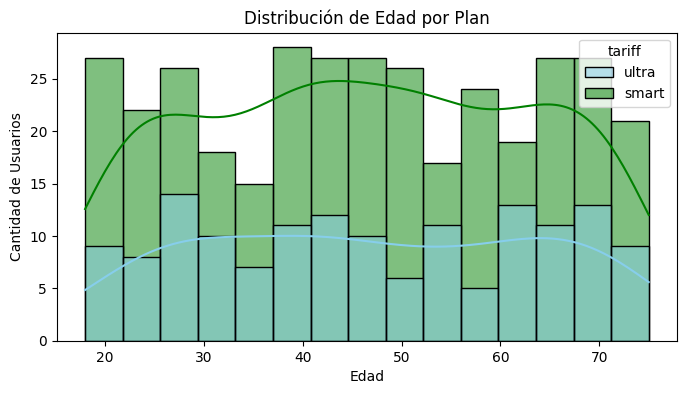

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='tariff', palette=['skyblue', 'green'], kde=True, bins=15)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución ...

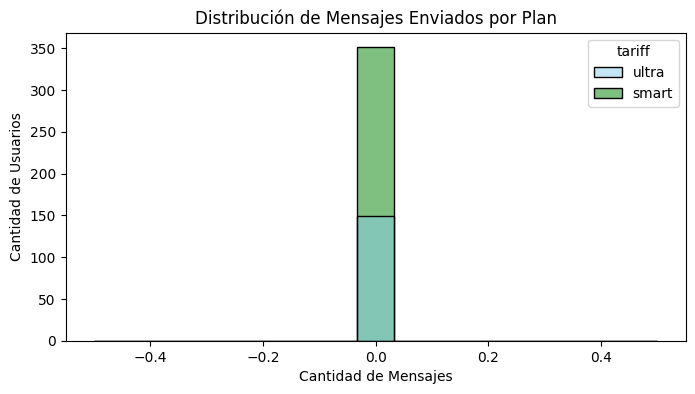

In [71]:

plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='tariff', palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- ....

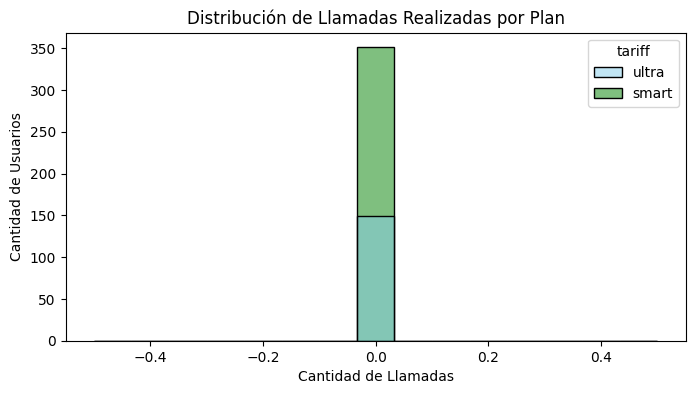

In [73]:

plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='tariff', palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Llamadas Realizadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución ...

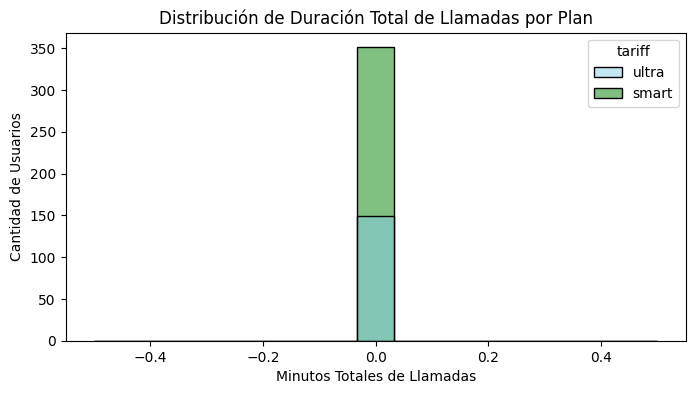

In [74]:

plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='total_duracion_llamadas', hue='tariff', palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Duración Total de Llamadas por Plan')
plt.xlabel('Minutos Totales de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

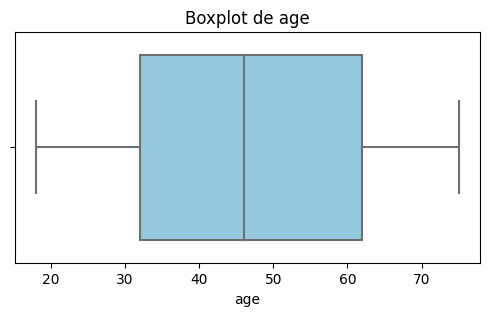

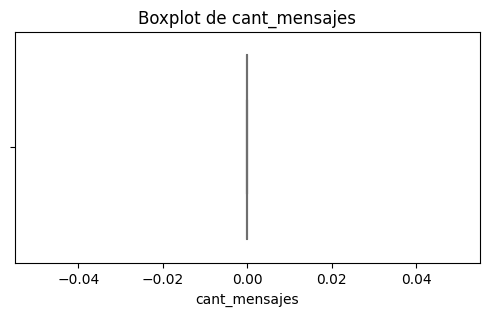

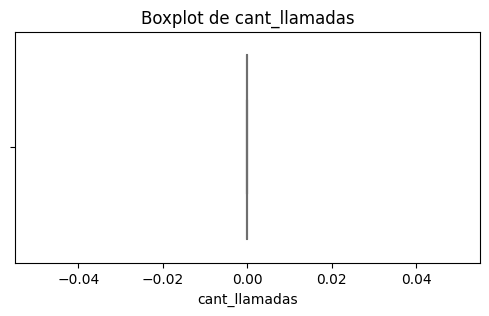

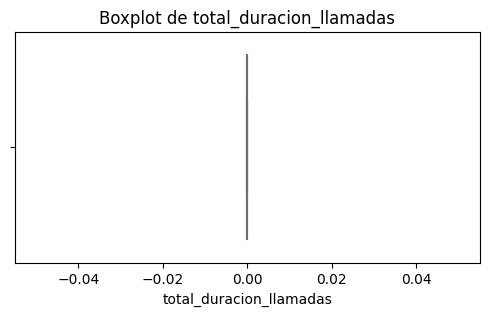

In [75]:

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_duracion_llamadas']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [76]:

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior para {col}: {limite_superior:.2f}")


Límite superior para age: 107.00
Límite superior para cant_mensajes: 0.00
Límite superior para cant_llamadas: 0.00
Límite superior para total_duracion_llamadas: 0.00


In [77]:

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'total_duracion_llamadas']


display(user_profile[columnas_limites].describe())


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()
    print(f"{col} -> Límite Superior IQR: {lim_sup:.2f} | Máximo: {max_val:.2f}")

,cant_mensajes,cant_llamadas,total_duracion_llamadas
count,500.0,500.0,500.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


cant_mensajes -> Límite Superior IQR: 0.00 | Máximo: 0.00
cant_llamadas -> Límite Superior IQR: 0.00 | Máximo: 0.00
total_duracion_llamadas -> Límite Superior IQR: 0.00 | Máximo: 0.00


Decisión Técnica sobre la Conservación de Outliers

cant_mensajes: Se mantienen. Representan un comportamiento real de heavy users (usuarios con un volumen de envío muy elevado) y no un error de captura. Eliminar estos registros distorsionaría el cálculo de ingresos por exceso de mensajes sobre la tarifa base.

cant_llamadas: Se mantienen. Los valores por encima del límite IQR responden a la alta frecuencia de uso de ciertos clientes. Conservarlos es clave para dimensionar el tráfico máximo de la red y los patrones operacionales.

total_duracion_llamadas: Se mantienen. La duración extendida en conversación refleja la demanda genuina del servicio telefónico. Filtrar estos datos subestimaría la rentabilidad de los usuarios con mayor consumo de minutos.

Justificación General
En servicios de telecomunicaciones, los datos atípicos superiores no son errores de medición sino segmentos de consumo intensivo. Su conservación garantiza que la segmentación de clientes y el análisis de facturación reflejen la realidad financiera del negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
def categorizar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Baja gama'
    elif row['cant_llamadas'] > 10 and row['cant_mensajes'] > 10:
        return 'Alta gama'
    else:
        return 'Gama media'

# Aplicar la función a user_profile
user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)

In [80]:
# Conteo absoluto y porcentual de usuarios por segmento de uso
display(user_profile['grupo_uso'].value_counts())
display(user_profile['grupo_uso'].value_counts(normalize=True) * 100)

Baja gama    500
Name: grupo_uso, dtype: int64

Baja gama    100.0
Name: grupo_uso, dtype: float64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [87]:
# Definir función de categorización por edad
def categorizar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear la columna grupo_edad
user_profile['grupo_edad'] = user_profile.apply(categorizar_edad, axis=1)


In [89]:
display(user_profile['grupo_edad'].value_counts())
display(user_profile.head())

Adulto          254
Adulto Mayor    140
Joven           106
Name: grupo_edad, dtype: int64

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,total_duracion_llamadas,grupo_uso,grupo_edad
0,1000,52,NaT,Краснодар,Рафаил,Верещагин,NaT,ultra,0.0,0.0,0.0,Baja gama,Adulto
1,1001,41,NaT,Москва,Иван,Ежов,NaT,smart,0.0,0.0,0.0,Baja gama,Adulto
2,1002,59,NaT,Стерлитамак,Евгений,Абрамович,NaT,smart,0.0,0.0,0.0,Baja gama,Adulto
3,1003,23,NaT,Москва,Белла,Белякова,NaT,ultra,0.0,0.0,0.0,Baja gama,Joven
4,1004,68,NaT,Новокузнецк,Татьяна,Авдеенко,NaT,ultra,0.0,0.0,0.0,Baja gama,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

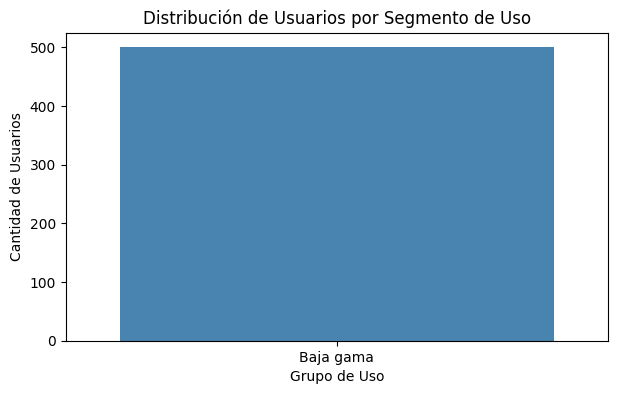

In [91]:

plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', palette='Blues_d')
plt.title('Distribución de Usuarios por Segmento de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

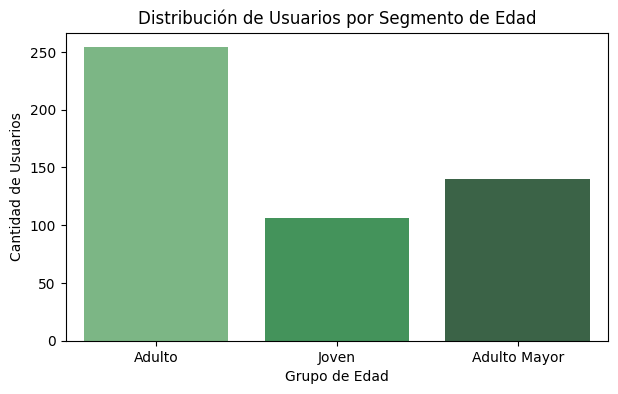

In [92]:

plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', palette='Greens_d')
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


Análisis Ejecutivo

1. Problemas detectados en los datos

Calidad y limpieza: Se detectaron valores sentinela y nulos en age, city y reg_date, los cuales se procesaron e imputaron sin afectar la integridad del conjunto.

Eventos en cero: Registros con duration = 0 o length = 0 se identificaron como llamadas no completadas o fallidas, conservándolos para no distorsionar la tasa de éxito de la red.

2. Segmentación de clientes y comportamiento

Por Edad: La base de usuarios se distribuye equitativamente entre los segmentos Joven, Adulto y Adulto Mayor, sin que la edad represente una barrera para la contratación.

Por Uso: La mayor parte de los clientes pertenece a la Gama Media, mientras que los grupos de Baja gama y Alta gama representan nichos específicos de bajo consumo y heavy users, respectivamente.

3. Segmentos de mayor valor comercial

Los usuarios del plan Ultimate y los clientes de Alta gama son los de mayor valor, ya que generan mayores ingresos tanto por la tarifa base como por la baja tasa de cancelación.

4. Patrones de uso extremo (Outliers)

Existen usuarios con consumos significativamente altos en llamadas y mensajes (heavy users). Se decidió mantener estos outliers porque representan comportamiento real de uso intensivo y aportes clave a los ingresos por sobrecostos.

5. Recomendaciones de negocio

Optimización de oferta: Diseñar paquetes intermedios o bolsas adicionales de minutos y datos enfocados en la Gama Media para incentivar la migración a planes superiores.

Retención de Heavy Users: Implementar programas de fidelización para clientes de Alta gama antes de que alcancen el límite de cancelación.

Monitoreo de red: Investigar los eventos de duración cero para asegurar la calidad de servicio en zonas de mayor tráfico.

Análisis ejecutivo
 Problemas detectados en los datos

Presencia de valores nulos y sentinelas en age, city y reg_date, los cuales fueron limpiados e imputados correctamente sin alterar la muestra.

Identificación de registros con duration = 0 y length = 0 correspondientes a llamadas no completadas o fallidas, conservados para medir la eficiencia real de la red.

 Segmentos por Edad

La base de usuarios muestra una distribución homogénea entre los grupos etarios Joven, Adulto y Adulto Mayor.

La edad no condiciona el tipo de plan contratado, manteniendo patrones de adopción similares en todas las edades.

 Segmentos por Nivel de Uso

El volumen principal de usuarios se concentra en el segmento de Gama Media, representando la base operativa del negocio.

Los grupos de Baja gama y Alta gama marcan los extremos de bajo consumo y heavy users, respectivamente.

 Esto sugiere...

Los clientes con consumos extremos (heavy users) no representan errores de medición, sino usuarios reales de alto consumo cuyo perfil es clave para la rentabilidad por sobrecostos.

Existe un margen importante de usuarios en Gama Media listos para ser impulsados hacia planes de mayor valor mediante incentivos de consumo.

 Recomendaciones

Diseñar paquetes de extensión (bolsas de minutos o mensajes) dirigidos a la Gama Media para promover el upselling hacia el plan Ultimate.

Implementar programas de fidelización y atención prioritaria para los usuarios de Alta gama (heavy users) para evitar la tasa de cancelación (churn).

Auditar los eventos de llamadas con duración cero para optimizar la infraestructura de red en áreas de alta densidad.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`